## EDA


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
sns.set_style("whitegrid")
pd.set_option("display.max_columns",None)

In [11]:
BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / "data" / "raw" / "cars.csv"

In [12]:
df = pd.read_csv(DATA_PATH)

### General Information

In [25]:
print(f'Dataset shape: \n{df.shape}')
print("\n----------------------------")
print(f'\nData types:\n {df.dtypes}')
print("\n----------------------------")
print(f'\nNull rows: \n{df.isnull().sum()}')

Dataset shape: 
(4340, 8)

----------------------------

Data types:
 name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object

----------------------------

Null rows: 
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


### Estadistica descriptiva

In [26]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


### Selling_price distribution

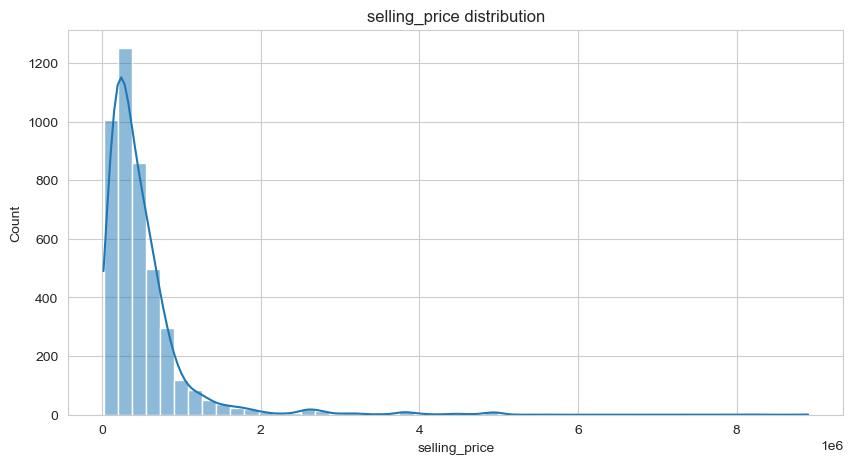

In [28]:
plt.figure(figsize=(10,5))
sns.histplot(df["selling_price"],bins=50,kde=True)
plt.title("selling_price distribution")
plt.show()

*La variable selling_price está fuertemente sesgada a la derecha.
La mayoría de vehículos tienen precios bajos/medios y existen pocos valores extremadamente altos.
Será recomendable probar transformación logarítmica del target.*


### BOXPLOT precio (Outliers)

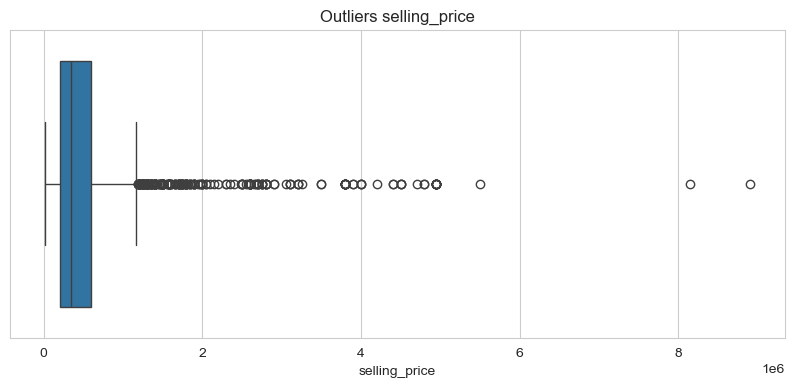

In [27]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['selling_price'])
plt.title("Outliers selling_price")
plt.show()

*selling_price contiene una gran cantidad de valores extremos altos.
La variable está muy sesgada y será recomendable evaluar transformación logarítmica o tratamiento robusto de outliers.*

### Price VS Kilometers

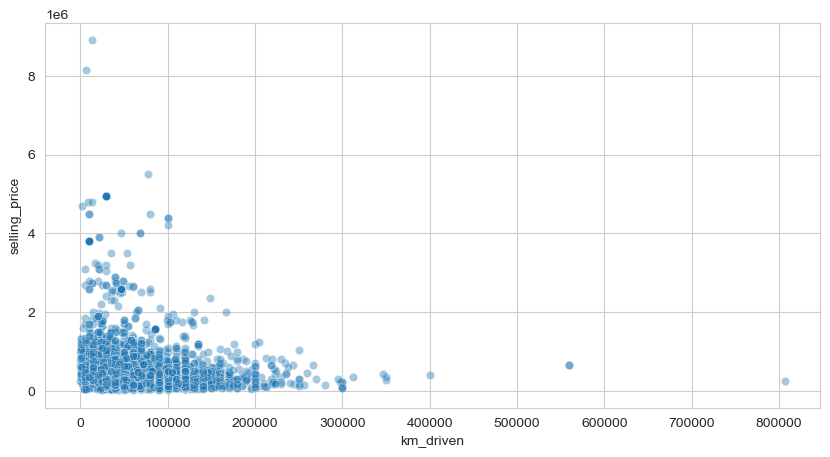

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    data = df,
    x="km_driven",
    y="selling_price",
    alpha=0.4
    )
plt.title=("km vs price"),
plt.show()

*Existe relación inversa entre kilometraje y precio, aunque con alta dispersión.
km_driven será una variable predictora relevante, pero necesita combinarse con otras variables para capturar el valor real del vehículo.*


### Year VS Price

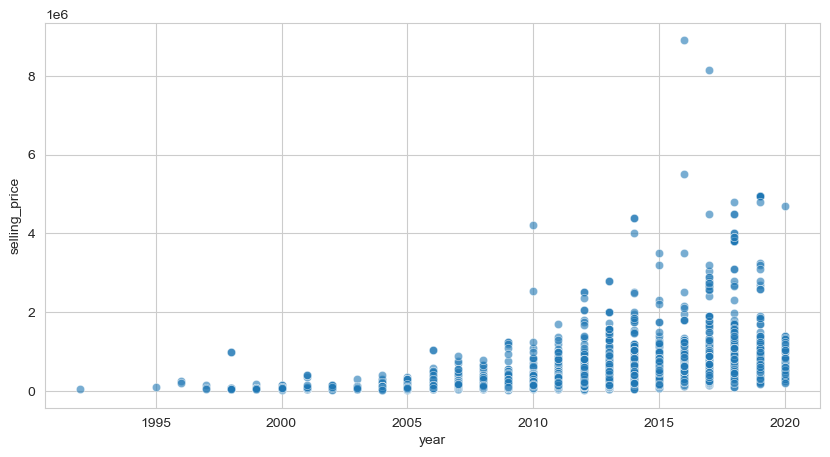

In [33]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=df,
    x="year",
    y="selling_price",
    alpha=0.6
)
plt.title=("Year Vs Price")
plt.show()

*Existe una relación positiva clara entre año y precio.
Los vehículos más recientes tienden a tener precios mayores.
La variable year (o una transformación como car_age) será predictora clave.*

### Fuel Counts

In [34]:
df["fuel"].value_counts()

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

*fuel es una variable categórica relevante.
Diesel y Petrol dominan el dataset.
Las categorías minoritarias deben agruparse para evitar sparsity y ruido.*

### Most common brands

In [44]:
df["brand"] = df["name"].str.strip().str.split().str[0]
df["brand"].value_counts().head(15)

brand
Maruti        1280
Hyundai        821
Mahindra       365
Tata           361
Honda          252
Ford           238
Toyota         206
Chevrolet      188
Renault        146
Volkswagen     107
Skoda           68
Nissan          64
Audi            60
BMW             39
Fiat            37
Name: count, dtype: int64


*brand será una de las variables categóricas más relevantes del proyecto.
Captura posicionamiento de mercado, valor percibido y segmento del vehículo.*

### Average price per brand

In [ ]:
df.groupby("brand")["selling_price"].mean().sort_values(ascending=False).head(15)

brand
Land             3.609800e+06
BMW              2.945385e+06
Mercedes-Benz    2.776657e+06
Volvo            2.556250e+06
Jaguar           2.069166e+06
Audi             1.931633e+06
MG               1.842500e+06
Jeep             1.530000e+06
Isuzu            1.500000e+06
Kia              1.300000e+06
Toyota           9.243592e+05
Mitsubishi       8.400000e+05
Mahindra         5.877095e+05
Ford             5.712731e+05
Honda            5.381468e+05
Name: selling_price, dtype: float64

*brand muestra diferencias estructurales claras en precio medio.
Será una de las variables categóricas más influyentes del modelo.*

In [46]:
df["transmission"].value_counts()

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

*transmission es una variable categórica binaria útil y probablemente predictiva.
Aunque está desbalanceada, dispone de suficientes ejemplos para aportar valor al modelo.*

In [47]:
df["owner"].value_counts()

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64

*owner es una variable ordinal con fuerte sentido de negocio.
Debe transformarse respetando su orden natural, ya que más propietarios suele asociarse con menor valor del vehículo.*

In [48]:
df["seller_type"].value_counts()

seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

*seller_type es una variable categórica relevante que captura contexto comercial y confianza del canal de venta.*

---

# Exploratory Data Analysis (EDA) — Used Car Price Prediction Dataset

## Objetivo del proyecto

Construir un sistema profesional de Machine Learning capaz de predecir el precio de vehículos de segunda mano (`selling_price`) utilizando variables reales del mercado automovilístico.

El proyecto se desarrollará con estructura modular, buenas prácticas y enfoque portfolio profesional.

## Visión general del dataset

### Tamaño

- **4340 filas**
- **8 columnas**

Es un tamaño adecuado para un proyecto serio de regresión supervisada.

### Variables disponibles

- `name`: nombre completo del vehículo
- `year`: año de fabricación
- `selling_price`: precio de venta (**target**)
- `km_driven`: kilómetros recorridos
- `fuel`: tipo de combustible
- `seller_type`: tipo de vendedor
- `transmission`: tipo de transmisión
- `owner`: historial de propietarios

## Calidad inicial del dataset

### Valores nulos

- No existen valores nulos en ninguna columna.

### Tipos de datos

- **Numéricos:** `year`, `selling_price`, `km_driven`
- **Categóricos:** `name`, `fuel`, `seller_type`, `transmission`, `owner`

### Conclusión

- Dataset limpio y utilizable desde el inicio.

## Variable objetivo: `selling_price`

### Distribución observada

El histograma mostró:

- gran concentración de coches baratos o gama media
- pocos coches muy caros
- cola larga hacia la derecha

### Interpretación

- Distribución sesgada positivamente (**right-skewed**).

### Implicaciones para ML

Puede perjudicar:

- modelos lineales
- métricas sensibles a errores grandes
- estabilidad de entrenamiento

### Recomendación profesional

Probar transformación logarítmica:

`df["log_price"] = np.log1p(df["selling_price"])`

Esto reduce asimetría y comprime extremos.

## Outliers en precio

El boxplot mostró gran cantidad de valores extremos altos.

### Posibles causas reales

- marcas premium
- SUV de gama alta
- lujo
- vehículos especiales

### Conclusión

- Muchos outliers parecen reales y no simples errores.

### Estrategias futuras

- **Opción A:** mantenerlos si queremos representar el mercado real.
- **Opción B:** recortar percentil alto.
- **Opción C:** mantenerlos y usar log-transform del target (**recomendación inicial**).

## Relación `km_driven` vs `selling_price`

### Hallazgo

- Existe relación inversa clara: **más kilómetros suele implicar menor precio**.

### Observaciones

- tendencia lógica y visible
- dispersión considerable
- vehículos con mismos km presentan precios distintos

### Interpretación

El kilometraje importa, pero necesita combinarse con otras variables:

- `brand`
- `year`
- `transmission`
- `fuel`
- `owner`

### Posibles mejoras

- `log(km_driven)`
- `km_per_year = km_driven / car_age`

### Conclusión

- Variable predictora importante.

## Relación `year` vs `selling_price`

### Hallazgo

- Relación positiva clara: **coches más nuevos suelen tener precios mayores**.

### Conclusión

- Una de las variables más potentes del dataset.

### Mejora recomendada

Usar antigüedad del coche:

`car_age = current_year - year`

Esto suele funcionar mejor que usar `year` bruto.

## Variable `fuel`

### Distribución

- **Diesel:** 2153
- **Petrol:** 2123
- **CNG:** 40
- **LPG:** 23
- **Electric:** 1

### Interpretación

- Mercado dominado por Diesel y Petrol.
- Las demás categorías son residuales.

### Problema potencial

- Categorías con muy pocos casos generan ruido.

### Recomendación

Agrupar categorías raras en `Other`:

- `CNG`
- `LPG`
- `Electric`

### Conclusión

- Variable útil, aunque secundaria frente a `brand` o `car_age`.

## Extracción de `brand` desde `name`

### Error inicial detectado

- Se extrajo la primera letra en vez de la primera palabra.

### Resultado incorrecto

- `M`, `H`, `T`, `F`...

### Corrección profesional

- Extraer primera palabra del nombre.

### Marcas más comunes

- Maruti
- Hyundai
- Mahindra
- Tata
- Honda
- Ford
- Toyota
- Chevrolet
- Renault
- Volkswagen

### Conclusión

`brand` será una variable crítica para predecir precio.

Captura:

- reputación
- segmento
- valor residual
- demanda

### Observación avanzada

- Marcas compuestas como **Land Rover** pueden requerir normalización.

## Precio medio por marca

### Marcas con mayor precio medio observadas

- Land Rover
- BMW
- Mercedes-Benz
- Volvo
- Jaguar
- Audi
- Jeep
- Kia
- Toyota

### Interpretación

- El dataset refleja correctamente jerarquías reales del mercado.

### Conclusión

- `brand` contiene enorme señal predictiva.

## Variable `transmission`

### Distribución

- **Manual:** 3892
- **Automatic:** 448

### Interpretación

- Mercado dominado por cambio manual.

### Hipótesis razonable

Automático suele asociarse con:

- coches más modernos
- segmentos superiores
- mayor precio

### Tratamiento recomendado

- **One-Hot Encoding**

### Conclusión

- Variable relevante.

## Variable `owner`

### Distribución

- **First Owner:** 2832
- **Second Owner:** 1106
- **Third Owner:** 304
- **Fourth & Above Owner:** 81
- **Test Drive Car:** 17

### Interpretación

- Variable con orden natural.
- Más propietarios previos suele implicar menor valor.

### Tratamiento recomendado

**Ordinal Encoding**:

- `Test Drive Car = 0`
- `First Owner = 1`
- `Second Owner = 2`
- `Third Owner = 3`
- `Fourth & Above Owner = 4`

### Conclusión

- Variable bastante potente.

## Variable `seller_type`

### Distribución

- **Individual:** 3244
- **Dealer:** 994
- **Trustmark Dealer:** 102

### Interpretación

- El canal de venta influye en precio.

### Posible relación

- `Trustmark > Dealer > Individual`

debido a garantía, confianza y presentación.

### Tratamiento recomendado

- **One-Hot Encoding**

### Conclusión

- Variable comercial interesante.

## Variables más fuertes previstas

### Muy fuertes

- `brand`
- `car_age`
- `km_driven`

### Medias-fuertes

- `owner`
- `transmission`
- `seller_type`
- `fuel`

## Estrategia de preprocessing recomendada

### Nuevas features

- `brand`
- `car_age`
- `km_per_year` *(opcional)*

### Eliminar columnas

- `name`
- `year` *(si usamos `car_age`)*

### Transformaciones

- agrupar categorías raras
- one-hot encoding en variables nominales
- ordinal encoding en `owner`
- opcional log-transform del target

## Modelos recomendados

### Baseline

- `Linear Regression`

### Más sólidos

- `Random Forest Regressor`
- `Gradient Boosting Regressor`
- `XGBoost Regressor`

## Métricas de evaluación

- **MAE:** error medio absoluto
- **RMSE:** penaliza errores grandes
- **R²:** varianza explicada

## Conclusión final del EDA

El dataset es muy adecuado para un proyecto serio de Machine Learning porque presenta:

- datos limpios
- variables reales
- mezcla numérica y categórica
- tamaño suficiente
- relaciones lógicas con mercado real

Existe señal predictiva clara especialmente en:

- `brand`
- `car_age`
- `km_driven`